In [418]:
%matplotlib inline

import h5py
import numpy as np
from matplotlib import pyplot as plt
import torch

import fastmri.data.transforms as T
from scipy.ndimage import gaussian_filter
from scipy.signal.windows import hann

In [512]:
file_path = '../mri_train_images/file1000027.h5'

hf = h5py.File(file_path, 'r')

In [513]:
print('Keys in the HDF5 file:', list(hf.keys()))
print('Attributes in the HDF5 file:', list(hf.attrs))

Keys in the HDF5 file: ['ismrmrd_header', 'kspace', 'reconstruction_esc', 'reconstruction_rss']
Attributes in the HDF5 file: ['acquisition', 'max', 'norm', 'patient_id']


In [514]:
hf.attrs['acquisition']

'CORPDFS_FBK'

In [515]:
# rss = hf['reconstruction_rss'][()]

# slice_id = 15
# singlecoil_kspace_slice = rss[slice_id]
# print(singlecoil_kspace_slice.shape)

# plt.imshow(np.log(np.abs(singlecoil_kspace_slice) + 1e-9), cmap="gray") 
# plt.show()

In [516]:
kspace = hf['kspace'][()]
# mask = hf['mask'][()]
# kspace = kspace * mask
print(kspace.dtype)
print(kspace.shape)

complex64
(34, 640, 368)


(640, 368)


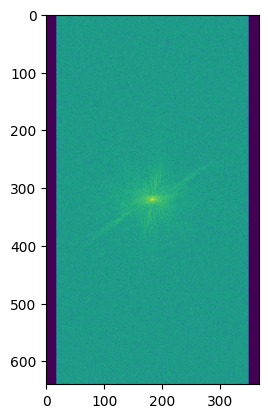

In [517]:
slice_id = 20
singlecoil_kspace_slice = kspace[slice_id]
print(singlecoil_kspace_slice.shape)

plt.imshow(np.log(np.abs(singlecoil_kspace_slice) + 1e-9))
plt.show()

In [518]:
singlecoil_kspace_tensor = T.to_tensor(kspace)
singlecoil_kspace_tensor.shape

torch.Size([34, 640, 368, 2])

In [519]:
singlecoil_sampled_image = fastmri.ifft2c(singlecoil_kspace_tensor)
singlecoil_sampled_image.shape

torch.Size([34, 640, 368, 2])

In [520]:
singlecoil_sampled_image_abs = fastmri.complex_abs(singlecoil_sampled_image)
singlecoil_sampled_image_abs.shape

torch.Size([34, 640, 368])

In [521]:
def show_slices(data, slice_nums, cmap=None):
    fig = plt.figure()
    for i, num in enumerate(slice_nums):
        plt.subplot(1, len(slice_nums), i + 1)
        print(data.shape)
        print(data.dtype)
        plt.imshow(data, cmap=cmap)


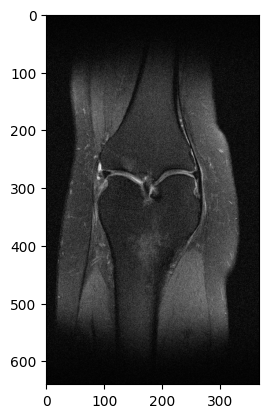

In [522]:
plt.imshow(singlecoil_sampled_image_abs[slice_id].numpy(), cmap="gray") # ?
plt.show()

In [523]:
#Normalize the image
singlecoil_sampled_image_abs = (singlecoil_sampled_image_abs - singlecoil_sampled_image_abs.min()) / (singlecoil_sampled_image_abs.max() - singlecoil_sampled_image_abs.min())

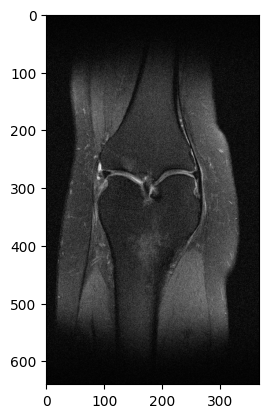

In [524]:
plt.imshow(singlecoil_sampled_image_abs[slice_id].numpy(), cmap="gray")
plt.show()

In [525]:
#Create bounding box for image ((100-150, 200-400)) (X,Y)

#Generate random coordinates inside bounding box to center screw
# x_min = np.random.randint(100, 150)
# y_min = np.random.randint(200, 400)

# #Replace area around location with cross pattern
# cross_size = 9
# thickness = 3
# for t in range(-thickness, thickness + 1):  # Loop to create thickness of the cross
#     for i in range(-cross_size, cross_size + 1):
#         if 0 <= x_min + i < singlecoil_sampled_image_abs.shape[2]:  # Check bounds for x
#             singlecoil_sampled_image_abs[slice_id, y_min + i, x_min + t] = np.random.rand()*0.05  # Set vertical line of cross
#         if 0 <= y_min + i < singlecoil_sampled_image_abs.shape[1]:  # Check bounds for y
#             singlecoil_sampled_image_abs[slice_id, y_min + t, x_min + i] = np.random.rand()*0.05  # Set horizontal line of cross

In [526]:
# Process to simulate metal artifact

# How to simulate this effect for a Gradient Echo vs a Spin Echo sequence

# First part: Simulate spatial shifts due to field inhomogeneity

# Assumptions: Original Image was collected with a Gradient

# Step 1: Map MRI image back to spatial (x,y) coordinates based on resolution

# Step 2: Calculate susceptibility map and overlay on spatial (x,y) grid

# Step 3: Shift all points in x direction according to inhomogeneity

# Step 4: Resample shifted points back onto original (x,y) grid

# Second part: Can you do the same thing in k-space? The shift in image space is spatially dependent

# Third part: Can you simulate intravoxel dephasing, given

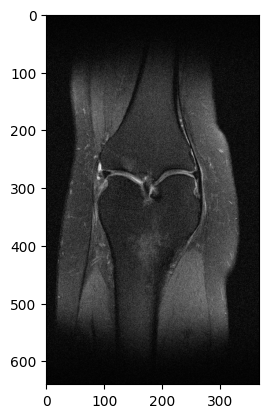

In [527]:
#display modified image
knee_img = singlecoil_sampled_image_abs[slice_id].numpy()
plt.imshow(knee_img, cmap="gray", aspect='equal')
plt.show()

In [528]:
# Function for spatial shift
def repeat_elements_norm(data, N):
    return [item / N for item in data for _ in range(N)]

print(repeat_elements_norm([1,2], 4))

[0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5]


In [529]:
def gaussian_field_map(a_mm=10.0, chi=3000e-5, B0_T=8, 
                       resolution_mm=0.5, extent_mm=40.0,
                       x_shift_mm=0, y_shift_mm=0):
    """
    R: Radial distance from center
    a_mm: Acts as the standard deviation (sigma) of the Gaussian
    chi: Used here as the scaling amplitude
    B0_T: Main magnetic field strength
    """

    n_samples = int(extent_mm / resolution_mm)
    extent_hw = extent_mm / 2  # Fixed: extent_mm/2 instead of int for linspace symmetry

    x = np.linspace(-extent_hw, extent_hw, n_samples)
    y = np.linspace(-extent_hw, extent_hw, n_samples)
    X, Y = np.meshgrid(x, y)
    
    # Calculate radial distance from the shifted center
    R2 = (X - x_shift_mm)**2 + (Y - y_shift_mm)**2
    
    # Amplitude scaling (matching your B0 * chi style)
    amplitude = B0_T * chi
    
    # Gaussian calculation: A * exp(-(x^2 + y^2) / (2 * sigma^2))
    delta_Bz = amplitude * np.exp(-R2 / (2 * a_mm**2))
    
    return delta_Bz

# function to return a susceptibility map for a cylinder

def cylinder_field_map(a_mm=10.0, chi=3000e-5, theta_rad=np.pi/2, 
                       B0_T=1.5, resolution_mm=0.5, extent_mm=40.0,
                       x_shift_mm=0, y_shift_mm=0):
    """
    R: Radial distance from cylinder axis
    Phi: Angular position (0 is aligned with the projection of B0)
    a: Cylinder radius
    theta_rad: Angle between B0 and cylinder axis (radians)
    resolution_mm
    """

    n_samples = int(extent_mm / resolution_mm)
    extent_hw = int(extent_mm / 2)

    x = np.linspace(-extent_hw, extent_hw, n_samples)
    y = np.linspace(-extent_hw, extent_hw, n_samples)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt((X-x_shift_mm)**2 + (Y-y_shift_mm)**2)
    Phi = np.arctan2((Y-y_shift_mm), (X-x_shift_mm))
    
    # Initialize field map
    delta_Bz = np.zeros_like(R)
    
    # Mask for inside vs outside
    inside = R <= a_mm
    outside = R > a_mm
    
    # Outside calculation
    delta_Bz[outside] = B0_T * (chi/2) * (a_mm/R[outside])**2 * (np.sin(theta_rad)**2) * np.cos(2*Phi[outside])
    
    # Inside calculation (Uniform field)
    delta_Bz[inside] = B0_T * (chi/6) * (3 * np.cos(theta_rad)**2 - 1)
    
    return delta_Bz

def center_crop(arr, crop_h, crop_w):
    # Get current height and width (assumes HWC or HW format)
    h, w = arr.shape[:2]
    
    # Calculate start points
    start_h = h // 2 - (crop_h // 2)
    start_w = w // 2 - (crop_w // 2)
    
    # Return the slice
    # The '...' (Ellipsis) handles extra dimensions like color channels
    return arr[start_h:start_h + crop_h, start_w:start_w + crop_w, ...]

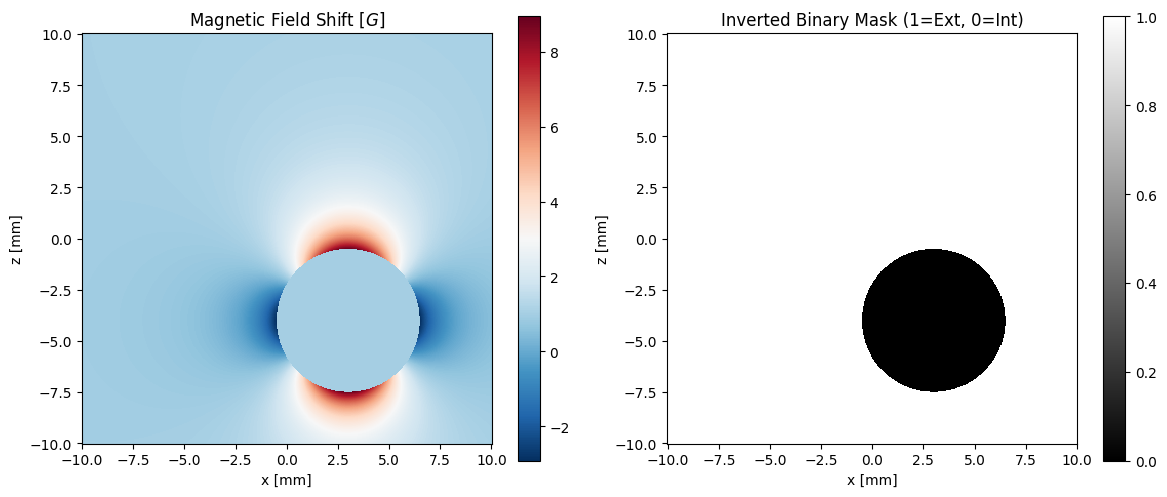

In [530]:
def generate_shifted_sphere_field_map_mm(
    grid_size_pixels: int = 400,
    extent_mm: float = 20.0,
    radius_a_mm: float = 3.5,
    center_x_mm: float = 3.0,
    center_z_mm: float = -4.0,
    chi_i: float = 50.0e-6,
    chi_e: float = 10.0e-6,
    B0_T: float = 3.0
):
    """
    Generates a 2D field map of a sphere shifted in the x and z directions.
    Also returns an inverted binary mask (1 for background, 0 for sphere).
    
    Returns:
    --------
    X_mm, Z_mm, field_map_T, inverted_mask
    """
    
    # Create coordinate grid
    coords = np.linspace(-extent_mm/2, extent_mm/2, grid_size_pixels)
    X_mm, Z_mm = np.meshgrid(coords, coords)
    
    # Calculate relative distance from the shifted center
    X_rel = X_mm - center_x_mm
    Z_rel = Z_mm - center_z_mm
    
    # Spherical coordinates relative to the shifted center
    R = np.sqrt(X_rel**2 + Z_rel**2)
    R_safe = np.where(R == 0, 1e-12, R) # Avoid division by zero
    CosTheta = Z_rel / R_safe
    
    # Baseline (k=0 term)
    baseline_T = (1/3) * chi_e * B0_T
    
    field_map_T = np.zeros_like(X_mm)
    internal_mask = R <= radius_a_mm
    external_mask = R > radius_a_mm
    
    # --- Generate Inverted Mask ---
    # ~internal_mask flips True to False and False to True. 
    # .astype(int) converts True/False to 1/0.
    inverted_mask = (~internal_mask).astype(int)
    
    # Internal Field: 1/3 * chi_e * B0
    field_map_T[internal_mask] = baseline_T
    
    # External Field: Dipole perturbation centered at (center_x, center_z)
    delta_chi = chi_i - chi_e
    dipole_geometry = (radius_a_mm**3 / R_safe[external_mask]**3) * (3 * CosTheta[external_mask]**2 - 1)
    
    field_map_T[external_mask] = (1/3) * delta_chi * dipole_geometry * B0_T + baseline_T
    
    return X_mm, Z_mm, field_map_T, inverted_mask

# --- Testing the output ---
X, Z, field, mask = generate_shifted_sphere_field_map_mm()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# convert to gauss
field_G = field*1e5

# Plot Field Map
im0 = ax[0].pcolormesh(X, Z, field_G, cmap='RdBu_r', shading='auto')
ax[0].set_title("Magnetic Field Shift [$G$]")
plt.colorbar(im0, ax=ax[0])

# Plot Inverted Mask
im1 = ax[1].pcolormesh(X, Z, mask, cmap='gray', shading='auto')
ax[1].set_title("Inverted Binary Mask (1=Ext, 0=Int)")
plt.colorbar(im1, ax=ax[1])

for a in ax:
    a.set_aspect('equal')
    a.set_xlabel('x [mm]')
    a.set_ylabel('z [mm]')

plt.tight_layout()
plt.show()

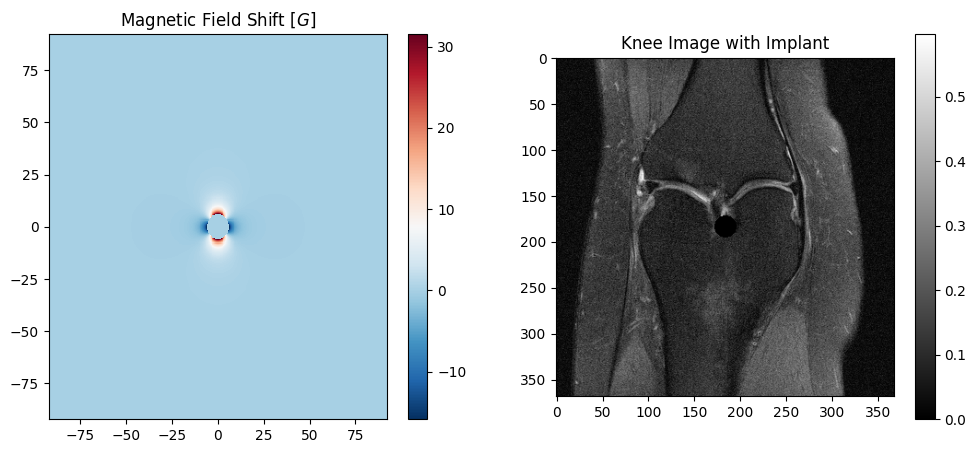

In [591]:
# scan parameters
knee_img_crop = center_crop(knee_img, knee_img.shape[1], knee_img.shape[1])

#gamma_over_2pi_Hz_per_G = 4258 # constant 
knee_img_resolution_mm = 0.5 # get this from the data (0.5mm x 0.5mm x 3.0mm)
knee_img_num_pixels = knee_img_crop.shape[0]
knee_img_extent_mm = knee_img_resolution_mm * knee_img_num_pixels
gradient_x_G_per_mm = 0.8 # estimate from known scanners (approx 8 G/cm for a 3T scanner)

# cylinder parameters
radius_a_mm = 6.0
center_x_mm = 0.0
center_z_mm = 0.0
chi_i = 1.8e-4 # constant for titanium: paramagnetic
chi_e = -1e-6 # constant for bone: weakly diamagnetic
B0_T = 3.0

X, Z, field_T, mask = generate_shifted_sphere_field_map_mm(grid_size_pixels=knee_img_num_pixels,
    extent_mm=knee_img_extent_mm,
    radius_a_mm=radius_a_mm,
    center_x_mm=center_x_mm,
    center_z_mm=center_z_mm,
    chi_i=chi_i,
    chi_e=chi_e,
    B0_T=B0_T)

field_G = field_T * 1e5

# generate knee image with cylindrical implant
knee_img_proc = knee_img_crop * mask

# plot susceptibility map
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Field Map
im0 = ax[0].pcolormesh(X, Z, field_G, cmap='RdBu_r', shading='auto')
ax[0].set_title("Magnetic Field Shift [$G$]")
plt.colorbar(im0, ax=ax[0])

# Plot Inverted Mask
im1 = ax[1].imshow(knee_img_proc, cmap='gray')
ax[1].set_title("Knee Image with Implant")
plt.colorbar(im1, ax=ax[1])

0.313558965921402


Text(0.5, 1.0, 'X-Slice of Field Shift Map, resolution 0.5 mm')

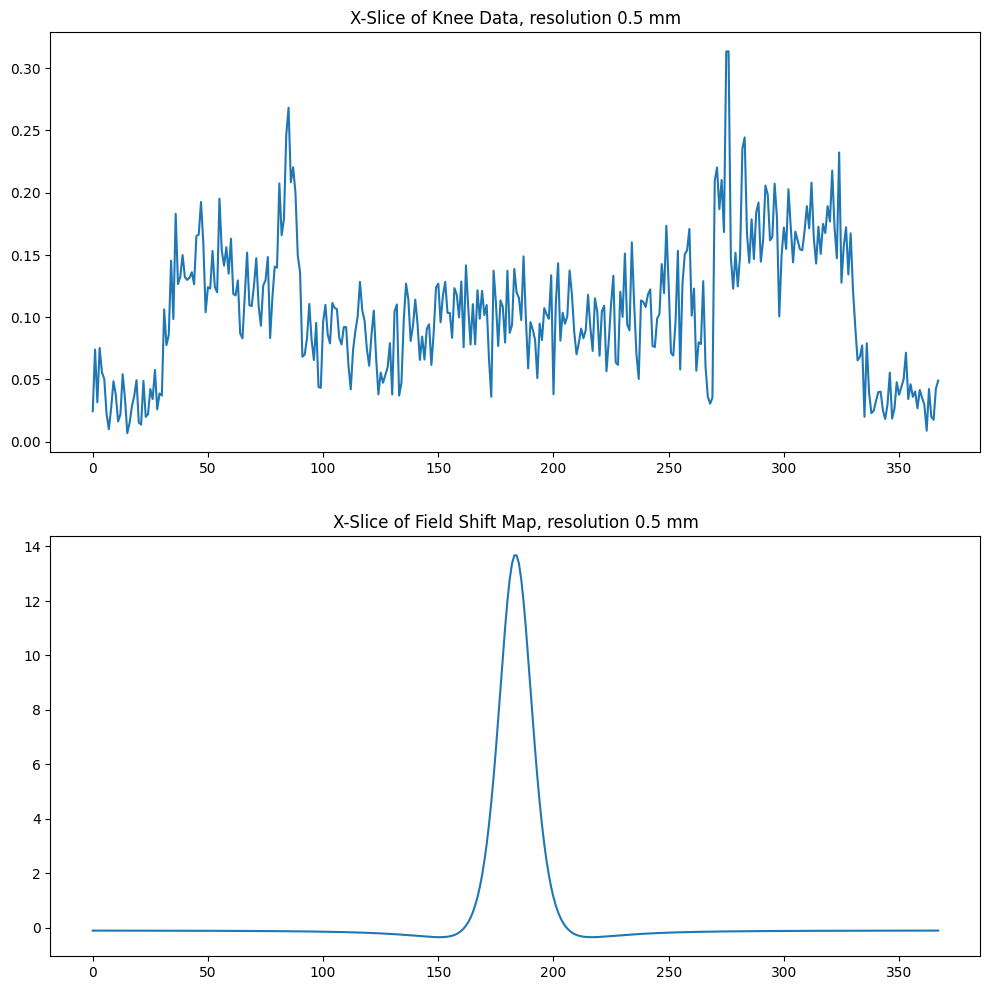

In [592]:
x_slice_img = knee_img_proc[200,:]
x_slice_susc_map = field_G[200,:]

print(x_slice_img.max())

fig, ax = plt.subplots(2,1,figsize=(12,12))
ax[0].plot(x_slice_img)
ax[0].set_title(f'X-Slice of Knee Data, resolution {img_delta_x_mm} mm')

ax[1].plot(x_slice_susc_map)
ax[1].set_title(f'X-Slice of Field Shift Map, resolution {susc_map_delta_x_mm} mm')

In [593]:
# 1d version of spins shifting based on susceptibility

def x_shift(x_slice, z_slice, x_slice_res_mm=0.5, upsample_factor=1):

    # final x slice
    x_slice_shift = np.zeros(x_slice.shape)

    # upsample the observed x values
    x_slice_up = repeat_elements_norm(x_slice, upsample_factor)
    x_slice_up_res_mm = x_slice_res_mm / upsample_factor # new resolution

    # create new susceptibility map at the desired resolution
    x_slice_extent_mm = x_slice_res_mm * x_slice.shape[0]
    susc_map_up = field_G # read in field shift map from above

    x_susc_map = susc_map_up[z_slice,:]
    
    # loop through x values and shift according to susceptibility map
    for i in range(len(x_slice_up)):
        x_shift = x_susc_map[i] / (gradient_x_G_per_mm * x_slice_up_res_mm)
        x_prime = int(np.round(i + x_shift))

        if x_prime >= 0 and x_prime < x_slice.shape[0]:
            x_slice_shift[x_prime] += x_slice_up[i]

    return x_slice_shift

In [594]:
# read in an x-slice of the original image, and plot next to the scaled susceptibility map

new_x_slice_img = x_shift(x_slice_img, z_slice=200, x_slice_res_mm=0.5)

Text(0.5, 1.0, 'X-Slice of Knee Data with Metal Artifacts, resolution 0.5 mm')

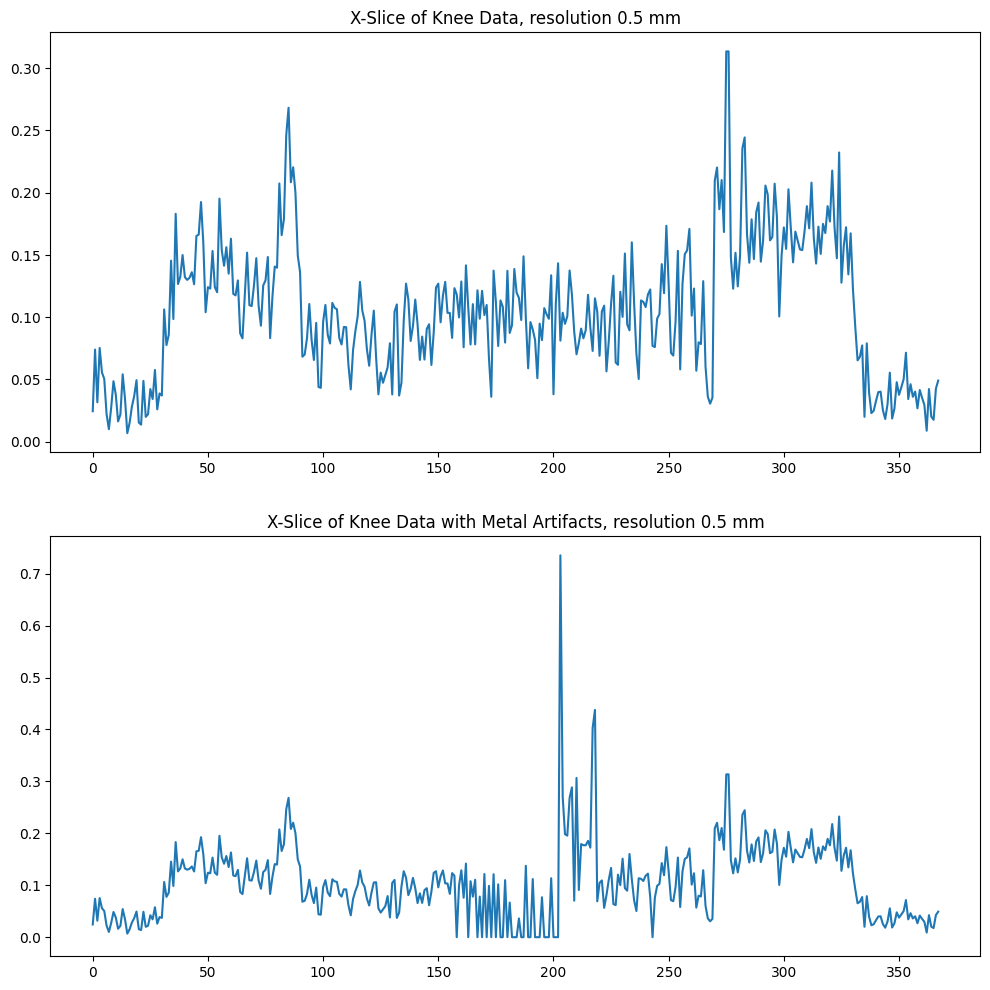

In [595]:
fig, ax = plt.subplots(2,1,figsize=(12,12))
ax[0].plot(x_slice_img)
ax[0].set_title(f'X-Slice of Knee Data, resolution {img_delta_x_mm} mm')

ax[1].plot(new_x_slice_img)
ax[1].set_title(f'X-Slice of Knee Data with Metal Artifacts, resolution {susc_map_delta_x_mm} mm')

In [596]:
# call 1d version as subroutine on image
def full_susceptibility_shift(img, x_slice_res_mm=0.5, cylinder_x_shift_mm=0, upsample_factor=1):

    final_img = np.zeros(img.shape)

    for i in range(img.shape[0]):
        curr_x_slice = img[i,:]
        x_slice_shift = x_shift(curr_x_slice,i,upsample_factor=upsample_factor)
        final_img[i,:] = x_slice_shift

    return final_img

Text(0.5, 1.0, 'Knee with Spherical Implant (Resolution: 0.5 mm)')

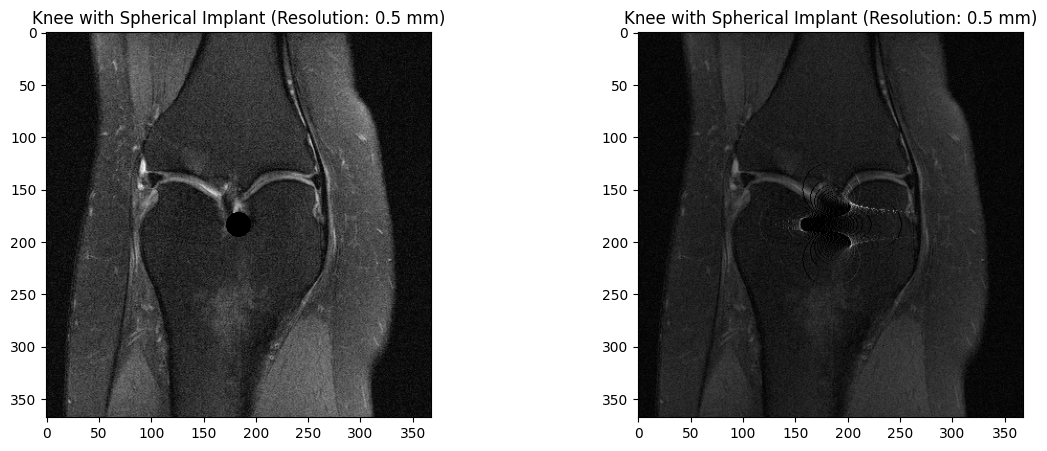

In [597]:
knee_img_with_artifacts = full_susceptibility_shift(knee_img_proc, upsample_factor=1)

fig, ax = plt.subplots(1,2,figsize=(14,5))

# plot original knee image
ax[0].imshow(knee_img_proc, cmap='gray')
ax[0].set_title(f'Knee with Spherical Implant (Resolution: {knee_img_resolution_mm} mm)')

# plot masked knee image
ax[1].imshow(np.log(1 + knee_img_with_artifacts), cmap='gray')
ax[1].set_title(f'Knee with Spherical Implant (Resolution: {knee_img_resolution_mm} mm)')